In [35]:
from visualization_helper_functions import Helper

# Evaluation of the models according to research methodology

In [38]:
outputs_folder = "new_outputs"
outputs_csv_folder = "new_tensorboard_csvs"
outputs_result_comparison_folder = "new_results_comparison"
outputs_outputs_folder = 'outputs'

In [40]:
experiments = ['solidity_detect_1/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_1_v1_19_1_BCE',
               'solidity_detect_1/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_1_v1_19_2_BCE',
               'solidity_detect_3/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_3_v1_19_1_BCE',
               'solidity_detect_3/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_3_v1_19_2_BCE',
               'solidity_detect_15/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_15_v1_19_1_BCE',
               'solidity_detect_15/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_15_v1_19_2_BCE']
experiment_results = dict()
for experiment in experiments:
    experiment_results[experiment] = Helper.extract_results(outputs_result_comparison_folder, experiment)

## Binary Classfication

In [ ]:
Helper.compare_two_models({'Binary': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['f1_score'], 
                           'Three classes': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score']})

## 3 Class Classification

In [ ]:
Helper.compare_two_models({'Binary': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['f1_score'], 
                           'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score']})

## 15 Class Classification

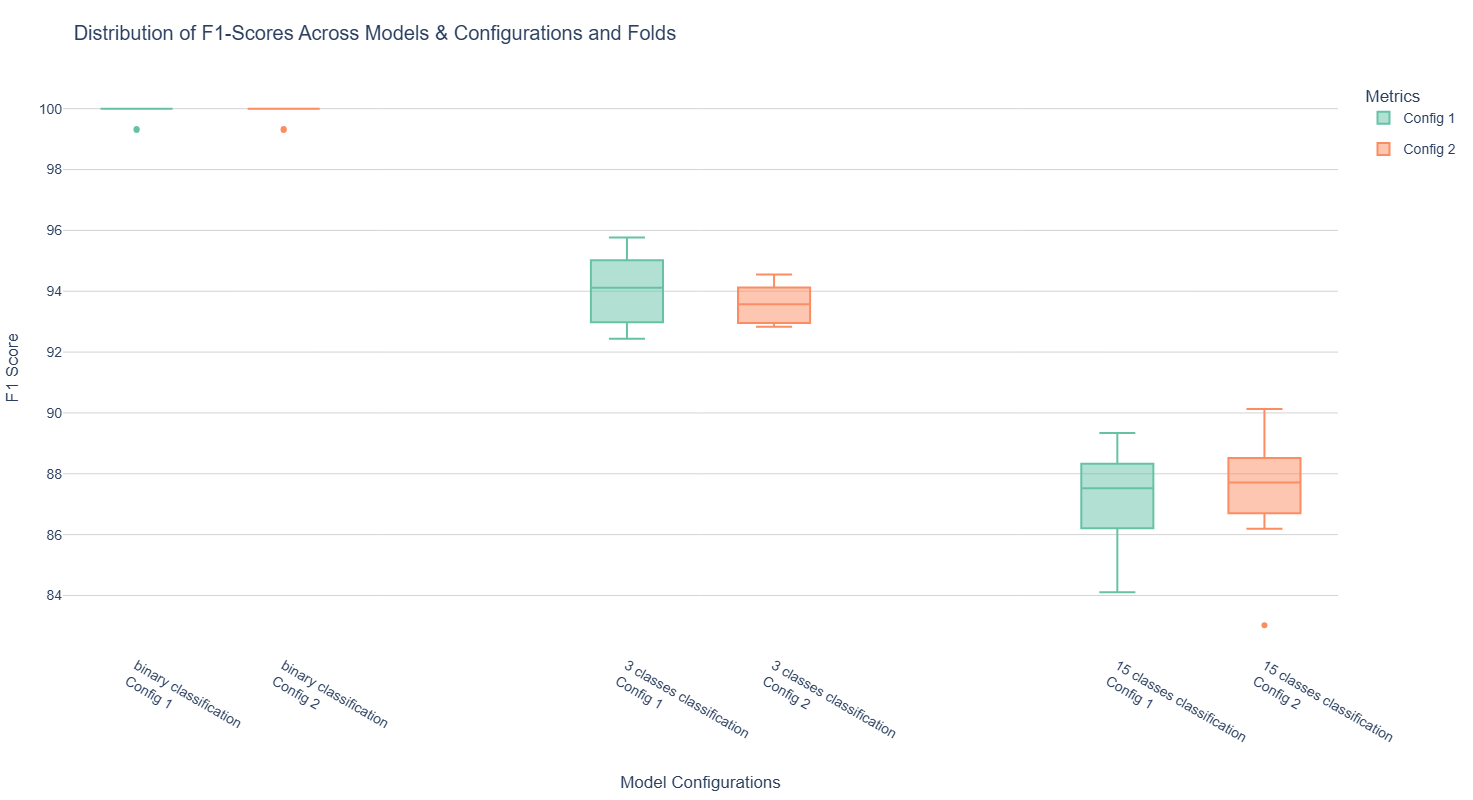

In [42]:
Helper.plot_grouped_boxplots({'binary classification': {'Config 1': experiment_results['solidity_detect_1/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_1_v1_19_1_BCE']['f1_score'],
                                               'Config 2': experiment_results['solidity_detect_1/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_1_v1_19_2_BCE']['f1_score']},
                      '3 classes classification': {'Config 1': experiment_results['solidity_detect_3/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_3_v1_19_1_BCE']['f1_score'],
                                     'Config 2': experiment_results['solidity_detect_3/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_3_v1_19_2_BCE']['f1_score']},
                      '15 classes classification': {'Config 1': experiment_results['solidity_detect_15/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_15_v1_19_1_BCE']['f1_score'],
                                      'Config 2': experiment_results['solidity_detect_15/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_15_v1_19_2_BCE']['f1_score']}},
                    fig_width=1000, fig_height=800, title="Distribution of F1-Scores Across Models & Configurations and Folds", x_label="Model Configurations", y_label="F1 Score", range_min=0.0, range_max=100.00)

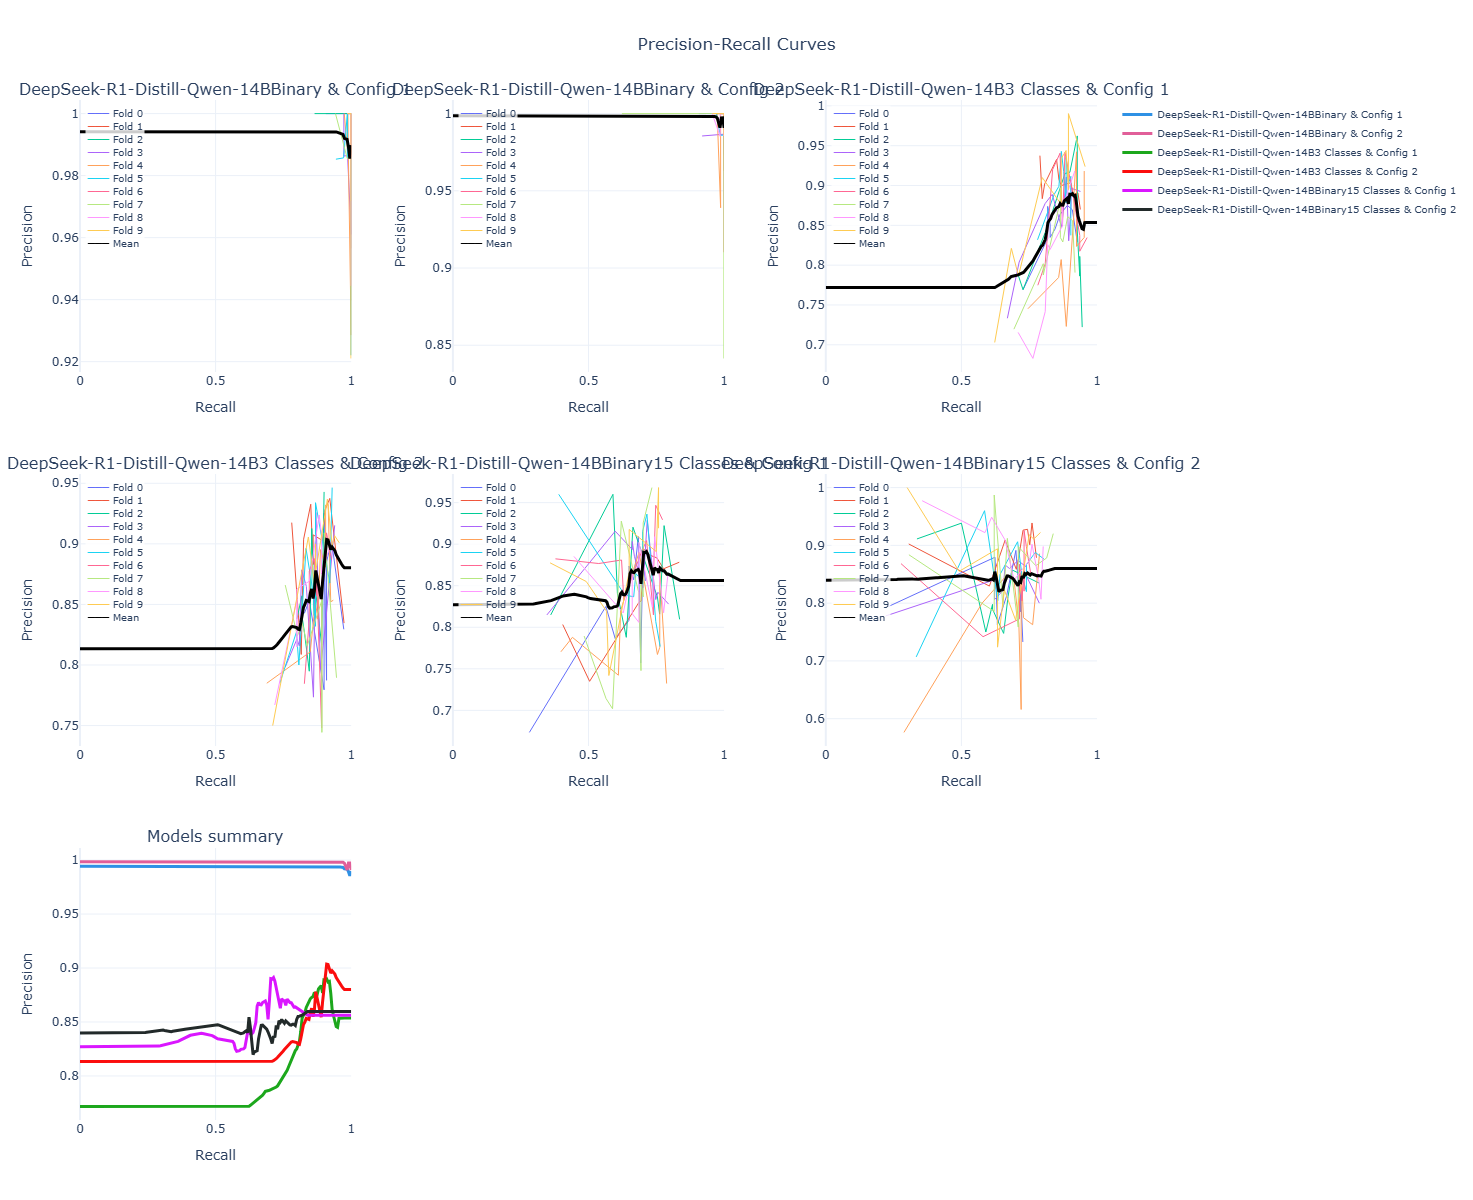

In [47]:
# pr_data = { model_name: { fold_idx: {'precision': array, 'recall': array}, ... }, ... }
import pandas as pd
min_steps = 10000000
sub_experiments = ['solidity_detect_1/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_1_v1_19_1_BCE',
               'solidity_detect_1/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_1_v1_19_2_BCE',
               'solidity_detect_3/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_3_v1_19_1_BCE',
               'solidity_detect_3/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_3_v1_19_2_BCE',
               'solidity_detect_15/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_15_v1_19_1_BCE',
               'solidity_detect_15/v1/DeepSeek_R1_Distill_Qwen_14B/exp_detection_solidity_detect_15_v1_19_2_BCE']
for experiment in sub_experiments:
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        min_steps_temp = min(len(val_precision), len(val_recall))
        min_steps = min(min_steps, min_steps_temp)

pr_data = dict()
for experiment in sub_experiments:
    model_name = experiment.split('/')[2].replace("_", "-")
    if '1' in experiment.split('/')[3].split("_")[4]:
        model_name += "Binary"
    if '3' in experiment.split('/')[3].split("_")[4]:
        model_name += "3 Classes"
    if '15' in experiment.split('/')[3].split("_")[4]:
        model_name += "15 Classes"
    if '1' in experiment.split('/')[3].split('_')[7]:
        model_name += " & Config 1"
    if '2' in experiment.split('/')[3].split('_')[7]:
        model_name += " & Config 2"
    pr_data[model_name] = dict()
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        pr_data[model_name][k] = {'precision': val_precision[:min_steps], 'recall': val_recall[:min_steps]}

#print(pr_data)

Helper.plot_precision_recall_curves(
        pr_data,
        summary_method='interpolation',
        template='plotly_white',
        fig_width=1200,
        fig_height=1200
    )